# Exercises — Getting familiar with your trading data

[DataCamp exercise](https://campus.datacamp.com/courses/financial-trading-in-python/trading-basics-1?ex=5) · see `Notes.md` in this folder for the summary.

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Locate the project's data folder regardless of where this notebook runs from
DATA = next(p / "course materials" / "data"
            for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "course materials" / "data").is_dir())

def load(name):
    """Load an OHLCV CSV with a parsed DatetimeIndex."""
    return pd.read_csv(DATA / name, index_col="Date", parse_dates=True)


### Explore, resample, returns, and SMA

In [7]:
tsla_data = load("TSLA-stock-data.csv")
print(tsla_data.head())

# Resample daily closes to weekly means
print(tsla_data["Close"].resample("W").mean().head())

             Open   High    Low  Close  Adj Close    Volume
Date                                                       
2015-12-18  46.58  47.18  45.86  46.09      46.09  15071000
2015-12-21  46.34  47.17  46.22  46.51      46.51   9766000
2015-12-22  47.00  47.31  45.93  45.99      45.99   9807500
2015-12-23  46.44  46.69  45.63  45.94      45.94   7775000
2015-12-24  46.11  46.38  45.66  46.11      46.11   3540000
Date
2015-12-20    46.0900
2015-12-27    46.1375
2016-01-03    47.2125
2016-01-10    43.7020
2016-01-17    41.1720
Freq: W-SUN, Name: Close, dtype: float64


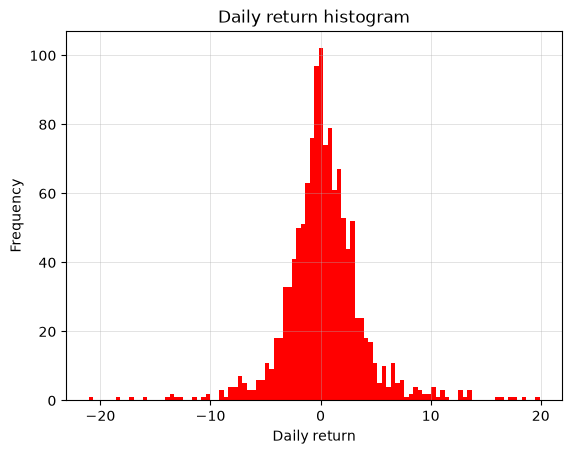

In [8]:
# Daily returns and their distribution
tsla_data["daily_return"] = tsla_data["Close"].pct_change() * 100
tsla_data["daily_return"].hist(bins=100, color="red")
plt.xlabel("Daily return"); plt.ylabel("Frequency"); plt.title("Daily return histogram")
plt.show()

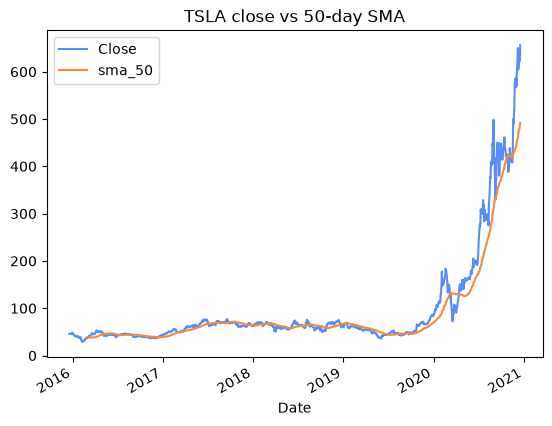

In [9]:
# 50-day SMA vs price
tsla_data["sma_50"] = tsla_data["Close"].rolling(50).mean()
tsla_data[["Close", "sma_50"]].plot(title="TSLA close vs 50-day SMA")
plt.show()

---

## Coding exercises in this section

The `script.py` starter for each Coding exercise under the **Getting familiar with your trading data** video (course exercises 6, 7, 8). Blanks (`____`) are as shown in DataCamp — fill them in to solve.

### 6. Resample the data

Depending on your trading strategy, you may want to trade at different frequencies — for example, moving from day trading to swing trading to position trading. Here you work with 4-hour EURUSD currency data (preloaded as `eurusd_4h`) and resample it to a daily frequency using mean values, then display the top 5 rows.

**Instructions**

- Resample `eurusd_4h` to daily frequency by calculating the mean values.
- Print the top 5 rows.

In [3]:
# `eurusd_4h` is preloaded on DataCamp. Here we generate a synthetic equivalent
# locally with the helper in this folder (see eurusd_4h.py) so the exercise runs.
from eurusd_4h import make_eurusd_4h

eurusd_4h = make_eurusd_4h()
print(eurusd_4h.head())

                      Open  Close   High    Low
Date                                           
2016-01-04 00:00:00  1.134  1.133  1.129  1.136
2016-01-04 04:00:00  1.133  1.134  1.132  1.135
2016-01-04 08:00:00  1.134  1.133  1.130  1.135
2016-01-04 12:00:00  1.133  1.138  1.135  1.140
2016-01-04 16:00:00  1.138  1.139  1.136  1.140


In [4]:
# Resample the data to daily by calculating the mean values
eurusd_daily = eurusd_4h.resample('D').mean()

# Print the top 5 rows
print(eurusd_daily.head())

# Resample the data to weekly by calculating the mean values
eurusd_weekly = eurusd_4h.resample('W').mean()

# Print the top 5 rows
print(eurusd_weekly.head())


                Open     Close      High       Low
Date                                              
2016-01-04  1.135167  1.135167  1.132333  1.137167
2016-01-05  1.144167  1.144000  1.142167  1.146833
2016-01-06  1.115500  1.109167  1.107167  1.110500
2016-01-07  1.101833  1.104500  1.103000  1.106500
2016-01-08  1.116167  1.115500  1.113167  1.117000
                Open     Close      High       Low
Date                                              
2016-01-10  1.118214  1.117738  1.115548  1.119619
2016-01-17  1.178190  1.180048  1.177429  1.181429
2016-01-24  1.170190  1.169643  1.167214  1.171357
2016-01-31  1.141405  1.140071  1.138190  1.141429
2016-02-07  1.116976  1.116405  1.113976  1.118000


### 7. Plot a return histogram

As a trader, it is important to analyze an asset's return profile, such as ranges of price changes and return distributions. Here you use Tesla historical daily price data (preloaded as `tsla_data`) to verify the stock's volatility. `matplotlib.pyplot` is imported as `plt`.

**Instructions**

- Calculate the daily percent change using the `Close` price and save it in a new column named `daily_return`.
- Plot a histogram of `daily_return`, setting the bin size to 100.

In [ ]:
# Calculate daily returns
tsla_data['daily_return'] = tsla_data['Close'].pct_change() * 100

# Plot the histogram
tsla_data['daily_return'].hist(bins=100, color='red')
plt.ylabel('Frequency')
plt.xlabel('Daily return')
plt.title('Daily return histogram')
plt.show()

### 8. Calculate and plot SMAs

Daily price data is inherently messy and noisy. A simple moving average (SMA) helps smooth it to reveal the trend. Here you analyze Apple stock data (preloaded as `aapl_data`) using a 50-day simple moving average. `matplotlib.pyplot` is imported as `plt`.

**Instructions**

- Calculate the 50-day SMA using the `Close` price, save it in a new column named `sma_50`.
- Plot a line chart using data from the `sma_50` and `Close` columns.

In [17]:
# `aapl_data` is preloaded on DataCamp. Here we generate a synthetic equivalent
# locally with the helper in this folder (see aapl_data.py) so the exercise runs.
from aapl_data import make_aapl_data

aapl_data = make_aapl_data()
print(aapl_data.head())

             Open   High    Low  Close  Adj Close     Volume
Date                                                        
2018-01-02  51.11  51.35  50.96  51.11      49.52  284321760
2018-01-03  50.85  51.40  50.75  51.33      49.74  116390548
2018-01-04  51.22  51.39  50.97  51.06      49.48   98343917
2018-01-05  51.25  52.42  51.18  52.38      50.76  105812011
2018-01-08  52.43  52.71  52.41  52.61      50.98   60492890


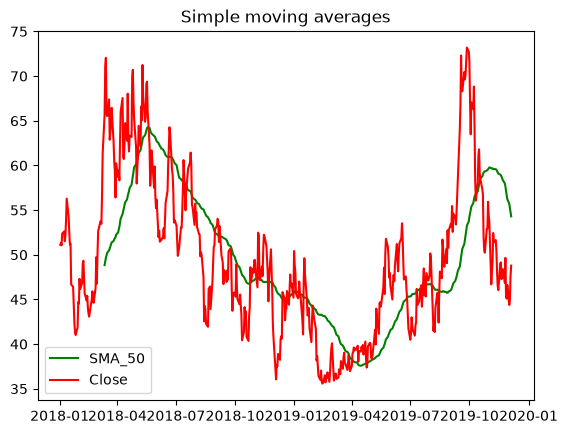

In [21]:
# Calculate SMA
aapl_data['sma_50'] = aapl_data['Close'].rolling(window=50).mean()

# Plot the SMA
plt.plot(aapl_data['sma_50'], color='green', label='SMA_50')
# Plot the close price
plt.plot(aapl_data['Close'], color='red', label='Close')

# Customize and show the plot
plt.title('Simple moving averages')
plt.legend()
plt.show()